In [1]:
import numpy as np
import matplotlib.pyplot as plt

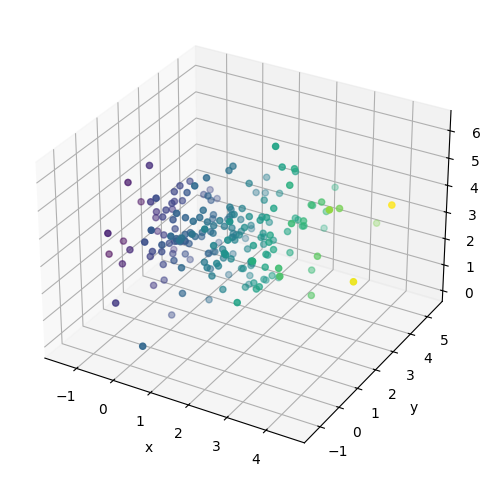

In [3]:
def gaussian_3d(x, y, z, mean, covariance):
    d = len(mean)
    sigma_det = np.linalg.det(covariance)
    if np.isclose(sigma_det, 0):
        return 1e-9

    x_centered = x - mean[0]
    y_centered = y - mean[1]
    z_centered = z - mean[2]

    det_term = 1 / (np.power(2 * np.pi * sigma_det, d / 2))
    exponent = -0.5 * ((x_centered.T @ np.linalg.inv(covariance) @ x_centered + y_centered.T @ np.linalg.inv(covariance) @ y_centered + z_centered.T @ np.linalg.inv(covariance) @ z_centered).squeeze())

    return det_term * np.exp(exponent)

N = 200
mean = [1, 2, 3]
covariance = [[1, 0.5, 0], [0.5, 1, 0], [0, 0, 1]]
X = np.random.multivariate_normal(mean, covariance, N).T

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[0], X[1], X[2], c=X[0])
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')

plt.show()